- softmax回归的从零开始实现
- 目的是了解softmax的实现细节

In [1]:
import torch
from IPython import display
from d2l import torch as d2l

batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)

- 将展平每个图像，将它们视为长度为784的向量。因为我们的数据集有10个类别，所以网络输出维度为10

In [2]:
num_inputs = 784
num_outputs = 10

w = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

- 实现softmax运算
$$\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_{k} \exp(\mathbf{X}_{ik})}.$$

In [3]:
def softmax(X):
    x_exp = torch.exp(X)
    partition = x_exp.sum(1, keepdim=True)  # keepdim=True保持维度不变
    return x_exp / partition  # 这里使用到了广播机制

- 我们将每一个元素变成非负数。此外，依据概率原理，每行元素的和为1

In [4]:
x = torch.normal(0, 1, (2, 5))
x_prob = softmax(x)
x_prob, x_prob.sum(1)

(tensor([[0.1103, 0.1288, 0.7087, 0.0391, 0.0132],
         [0.2632, 0.2176, 0.1261, 0.3393, 0.0538]]),
 tensor([1., 1.]))

- 实现softmax回归模型

In [5]:
def net(X):
    return softmax(torch.matmul(X.reshape((-1, w.shape[0])), w) + b)

In [6]:
# 创建一个数据y_hat，其中包含2个样本在3个类别上的预测值，使用y作为y_hat中概率的索引
y = torch.tensor([0, 2])
y_hat = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])
y_hat[[0, 1], y]

tensor([0.1000, 0.5000])

- 实现交叉熵损失函数

In [7]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y])
cross_entropy(y_hat, y)

tensor([2.3026, 0.6931])

- 将预测值类别与真实y元素进行比较

In [8]:
def accuracy(y_hat, y): #@save
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())
accuracy(y_hat, y) / len(y)

0.5

- 我们可以评估在任意模型net的准确率

In [9]:
def evaluate_accuracy(net, data_iter): #@save
    """评估在指定数据集上模型的准确率"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = d2l.Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

- Accumulator类

In [10]:
class Accumulator:  #@save
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]
evaluate_accuracy(net, test_iter)

0.0676

- softmax回归的训练

In [11]:
def train_epoch_ch3(net,train_iter,loss,updater): #@save
    if isinstance(net,torch.nn.Module):
        net.train()  # 将模型设置为训练模式
    metric = d2l.Accumulator(3)  # 损失总和、正确预测数、预测总数
    for X,y in train_iter:
        y_hat = net(X)
        l = loss(y_hat,y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            updater.step()
            metric.add(float(l)*len(y),accuracy(y_hat,y),y.size().numel())
        else:
            l.sum().backward()
            updater(X.shape[0])
            metric.add(float(l.sum()),accuracy(y_hat,y),y.size().numel())
    return metric[0]/metric[2], metric[1]/metric[2]

- 定义一个动画中绘制数据的实用程序

In [12]:
class Animator:  #@save
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        # 增量地绘制多条线
        if legend is None:
            legend = []
        d2l.use_svg_display()
        self.fig, self.axes = d2l.plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        # 使用lambda函数捕获参数
        self.config_axes = lambda: d2l.set_axes(
            self.axes[0], xlabel, ylabel, xlim, ylim, xscale, yscale, legend)
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        # 向图表中添加多个数据点
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)
        self.axes[0].cla()
        for x, y, fmt in zip(self.X, self.Y, self.fmts):
            self.axes[0].plot(x, y, fmt)
        self.config_axes()
        display.display(self.fig)
        display.clear_output(wait=True)

- 训练函数

In [13]:
def train_ch3(net,train_iter,test_iter,loss,num_epochs,updater): #@save
    animator = Animator(xlabel='epoch', xlim=[1, num_epochs], ylim=[0.3, 0.9],
                        legend=['train loss', 'train acc', 'test acc'])
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        animator.add(epoch + 1, train_metrics + (test_acc,))
    train_loss, train_acc = train_metrics

- 小批量随机梯度下降来优化模型参数

In [14]:
lr = 0.1
def updater(batch_size):
    return d2l.sgd([w, b], lr, batch_size)

- 训练模型10个迭代周期

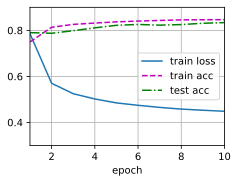

In [15]:
num_epochs = 10
train_ch3(net, train_iter, test_iter, cross_entropy, num_epochs, updater)

- 对图像进行分类预测

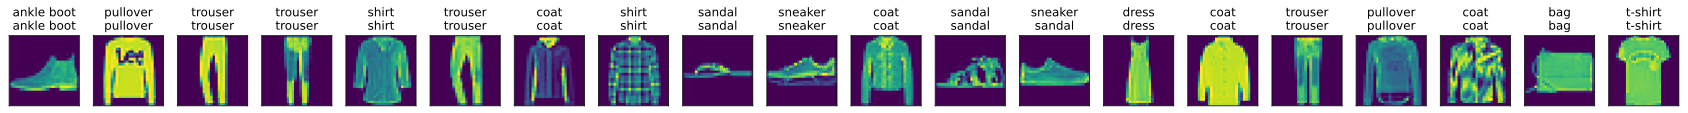

In [16]:
def predict_ch3(net, test_iter, n=20): #@save
    for X, y in test_iter:
        break
    trues = d2l.get_fashion_mnist_labels(y)
    preds = d2l.get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true +'\n' + pred for true, pred in zip(trues, preds)]
    d2l.show_images(
        X[0:n].reshape((n, 28, 28)), 1, n, titles=titles[0:n])
predict_ch3(net, test_iter)

- 附录

In [17]:
# 对矩阵的加运算
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))